# P3R HLDA lambda diagnostics

This notebook compares P3R to WT and neighboring P3* mutants to understand why lambda looks like an outlier.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from common.utils import load_lambda_grid

sns.set_theme(style='whitegrid', context='paper', font='DejaVu Sans')
%config InlineBackend.figure_format = 'retina'


In [2]:
data_dir = repo_root / 'data'
traj_dir = data_dir / 'traj'
lambda_cache = data_dir / 'hlda_lambda_grid.pkl'

lambda_grid = load_lambda_grid(cache_path=lambda_cache, force=False)


In [3]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=None, vmax=None, cmap='viridis'):
    P = df.pivot(index='tF', columns='tU', values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='flat'
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{int(round(val))}", ha='center', va='center', fontsize=6)

    ax.set_xlabel('tU')
    ax.set_ylabel('tF')
    ax.set_title(title, fontsize=9)
    return im


In [4]:
def load_rmsd(mutant, suffix):
    path = traj_dir / mutant / suffix
    return np.loadtxt(path, comments='#', usecols=[1])


def summarize_rmsd(mutant):
    rmsd_F = load_rmsd(mutant, 'COLVAR_CV_F')
    rmsd_U = load_rmsd(mutant, 'COLVAR_CV_UF')
    qF = np.quantile(rmsd_F, [0.05, 0.5, 0.95])
    qU = np.quantile(rmsd_U, [0.05, 0.5, 0.95])
    return rmsd_F, rmsd_U, qF, qU


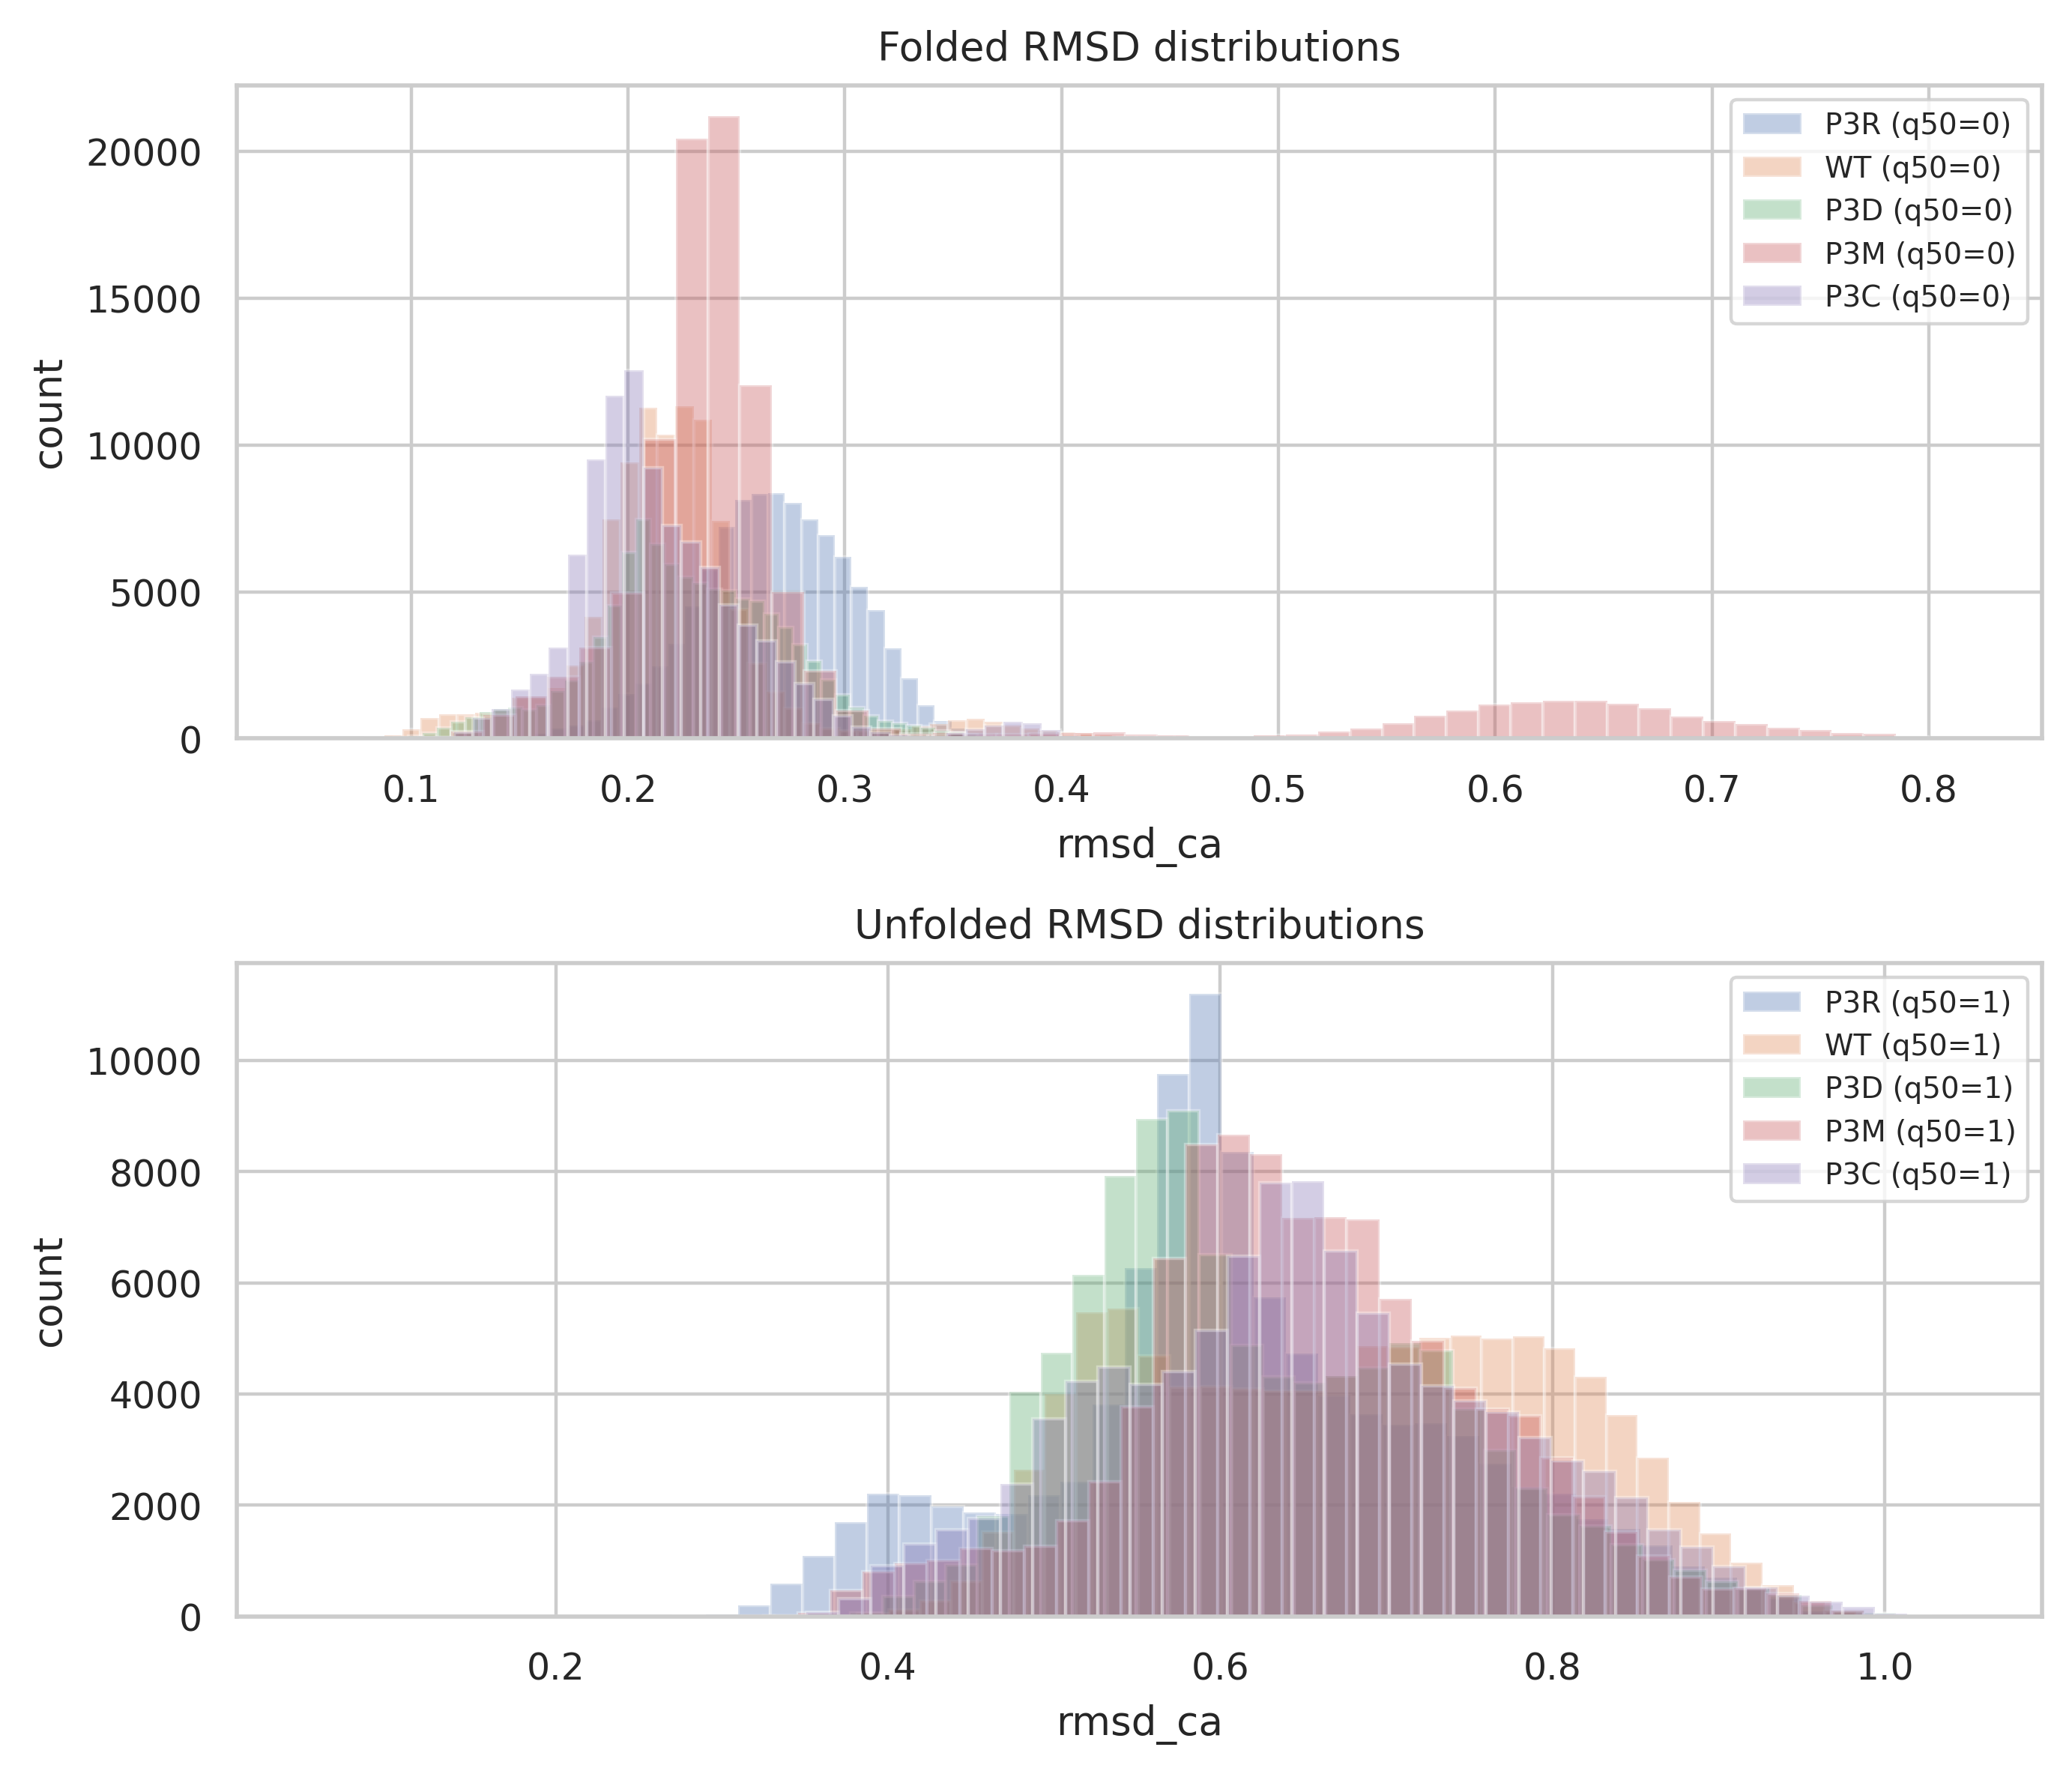

In [5]:
# RMSD distributions: P3R vs WT vs other P3 mutants
mutants = ['P3R', 'WT', 'P3D', 'P3M', 'P3C']

fig, axes = plt.subplots(2, 1, figsize=(7, 6), dpi=200)
for mut in mutants:
    rmsd_F, rmsd_U, qF, qU = summarize_rmsd(mut)
    axes[0].hist(rmsd_F, bins=50, alpha=0.35, label=f"{mut} (q50={int(round(qF[1]))})")
    axes[1].hist(rmsd_U, bins=50, alpha=0.35, label=f"{mut} (q50={int(round(qU[1]))})")

axes[0].set_title('Folded RMSD distributions')
axes[0].set_xlabel('rmsd_ca')
axes[0].set_ylabel('count')
axes[0].legend(fontsize=7)

axes[1].set_title('Unfolded RMSD distributions')
axes[1].set_xlabel('rmsd_ca')
axes[1].set_ylabel('count')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


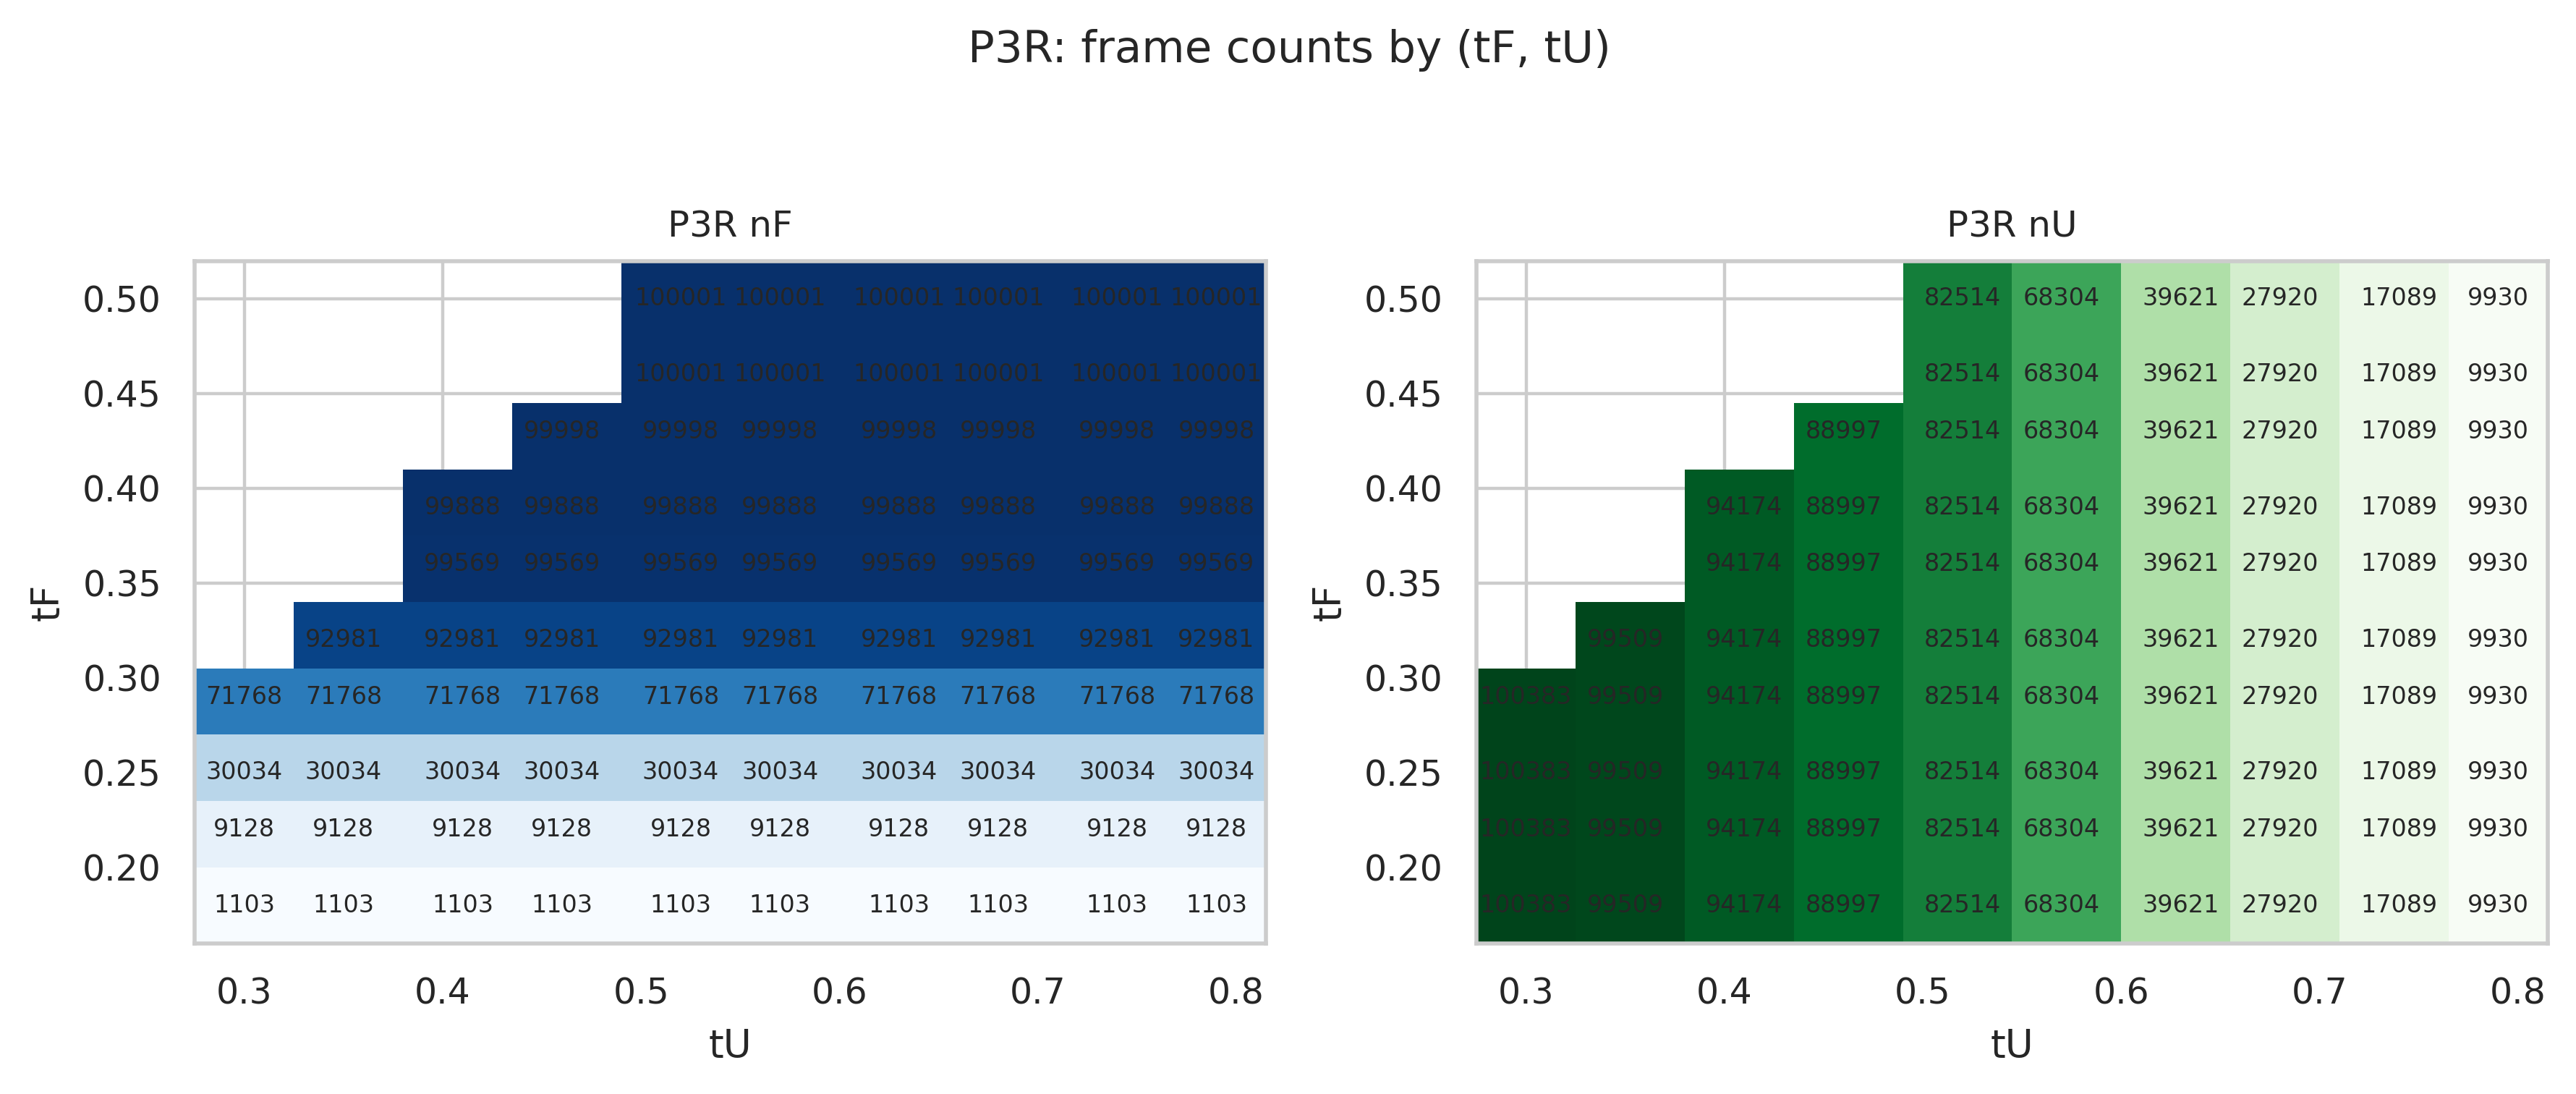

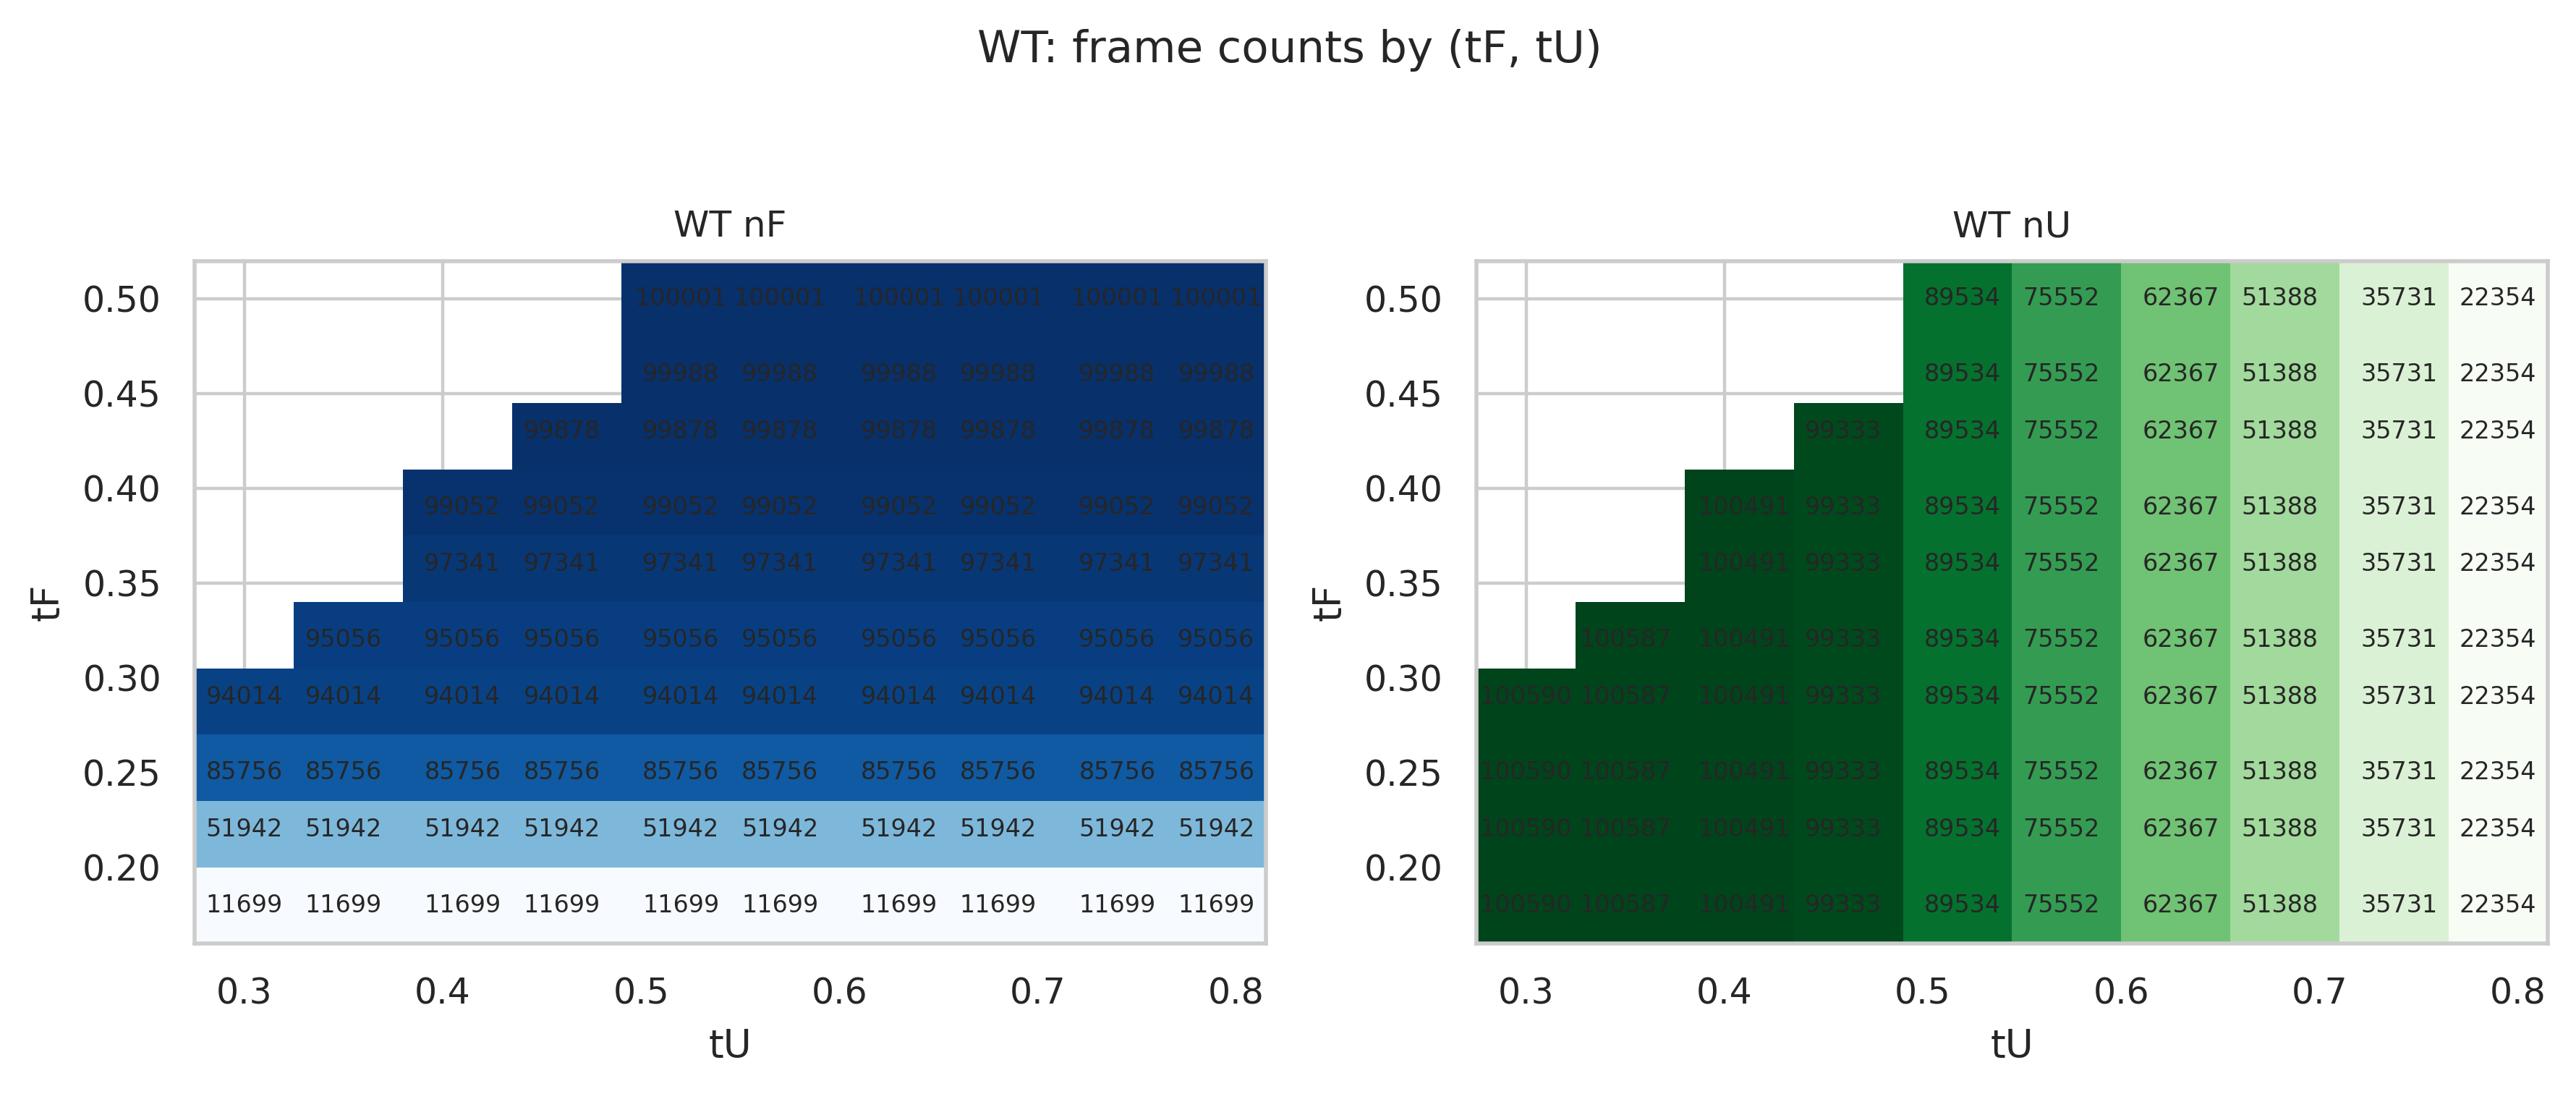

In [6]:
# nF/nU heatmaps for P3R vs WT

def counts_for_thresholds(mutant, tF_grid, tU_grid):
    rmsd_F = load_rmsd(mutant, 'COLVAR_CV_F')
    rmsd_U = load_rmsd(mutant, 'COLVAR_CV_UF')
    rows = []
    for tF in tF_grid:
        nF = int(np.sum(rmsd_F <= tF))
        for tU in tU_grid:
            if tU <= tF:
                continue
            nU = int(np.sum(rmsd_U >= tU))
            rows.append({'tF': float(tF), 'tU': float(tU), 'nF': nF, 'nU': nU})
    return pd.DataFrame(rows)

unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())

for mut in ['P3R', 'WT']:
    df_counts = counts_for_thresholds(mut, unique_tf, unique_tu)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), dpi=200)
    plot_heatmap_in_ax(axes[0], df_counts, 'nF', f"{mut} nF", cmap='Blues')
    plot_heatmap_in_ax(axes[1], df_counts, 'nU', f"{mut} nU", cmap='Greens')
    fig.suptitle(f"{mut}: frame counts by (tF, tU)", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


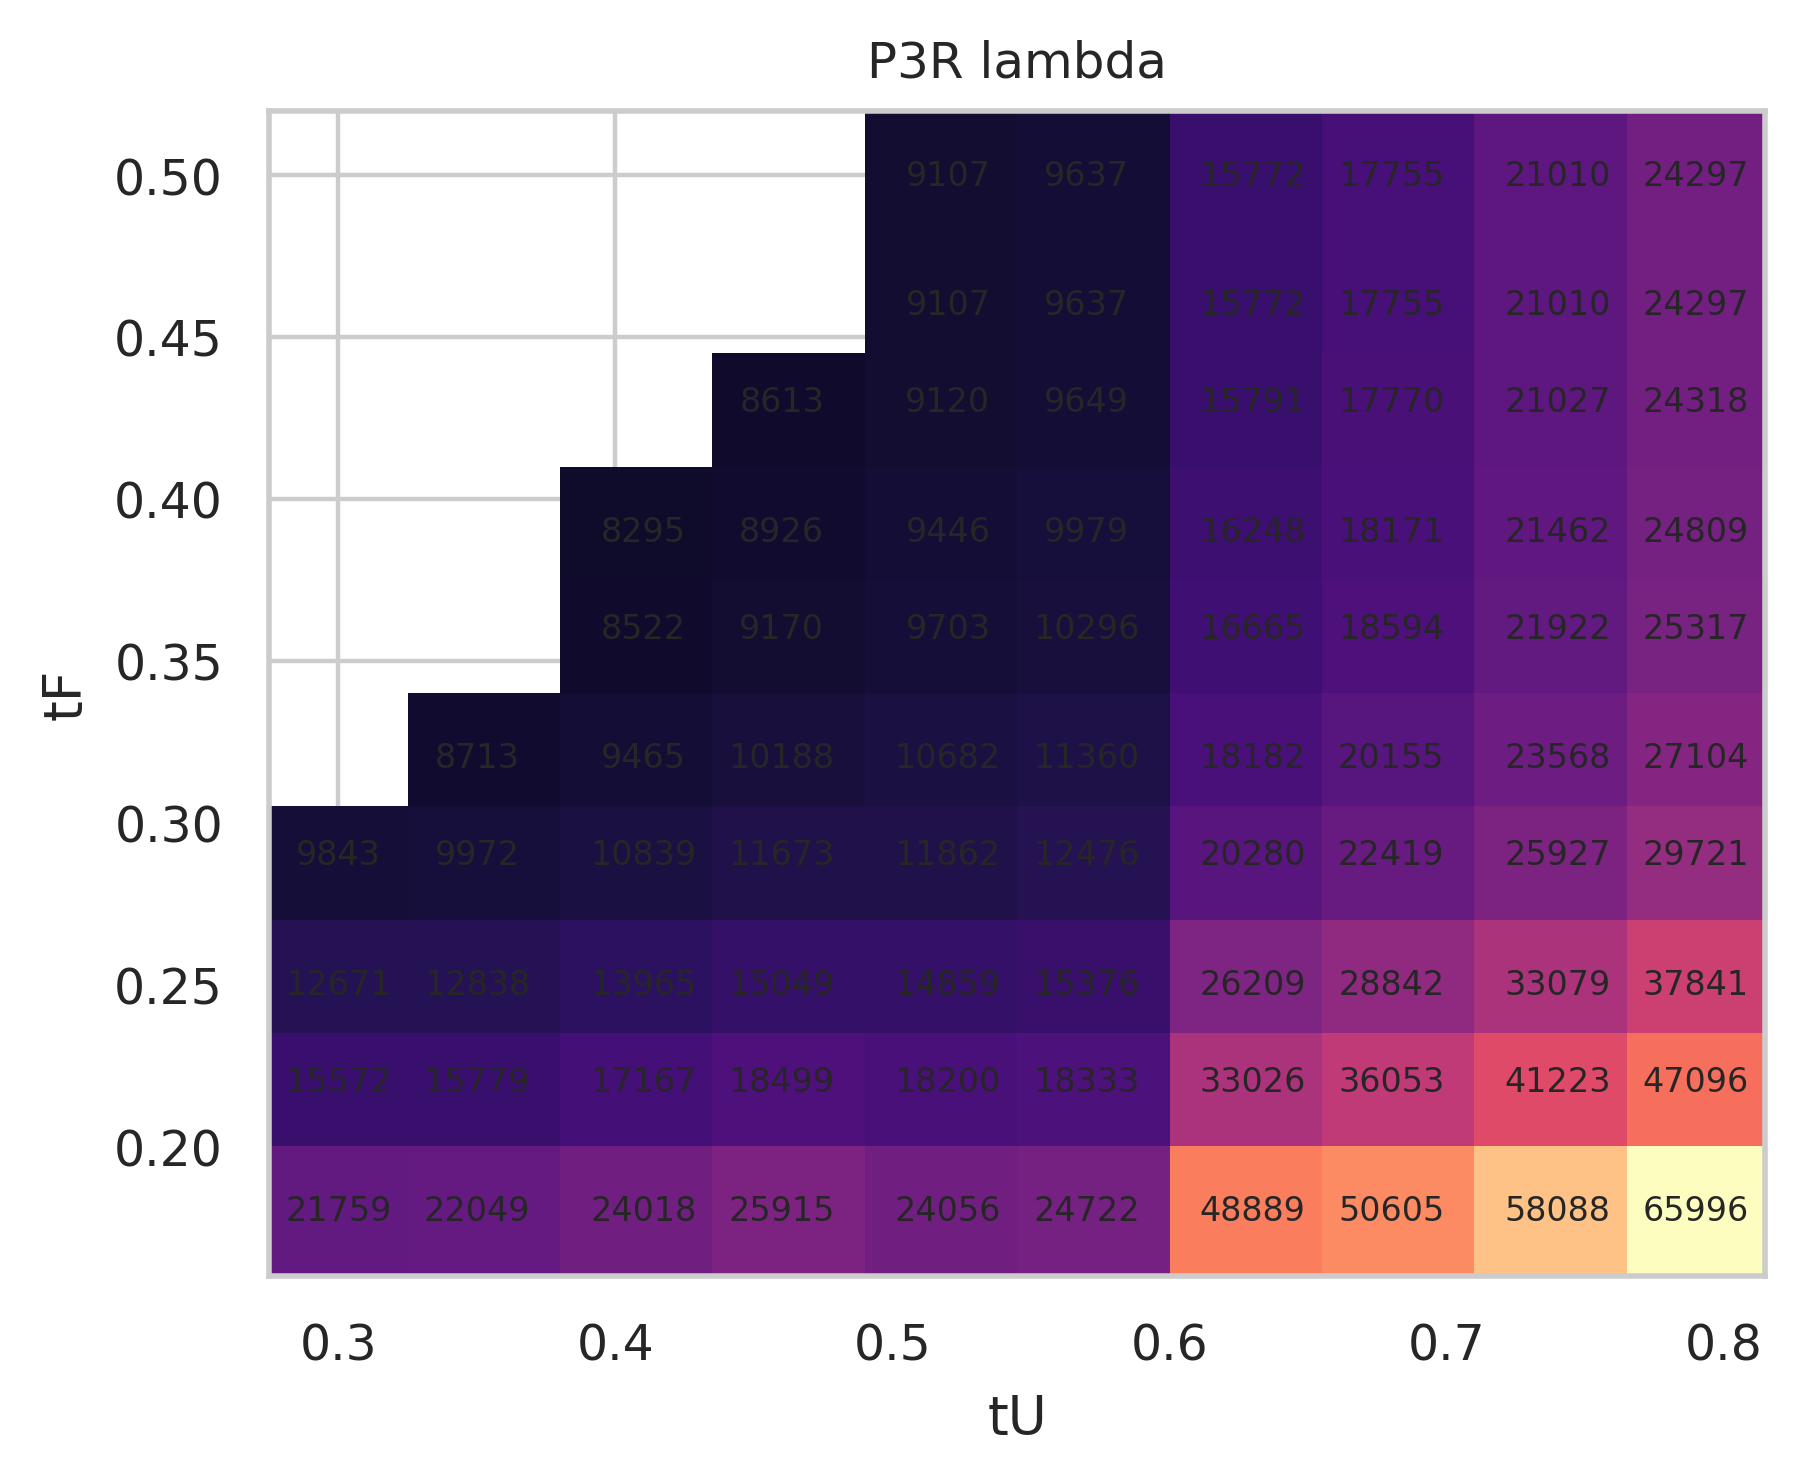

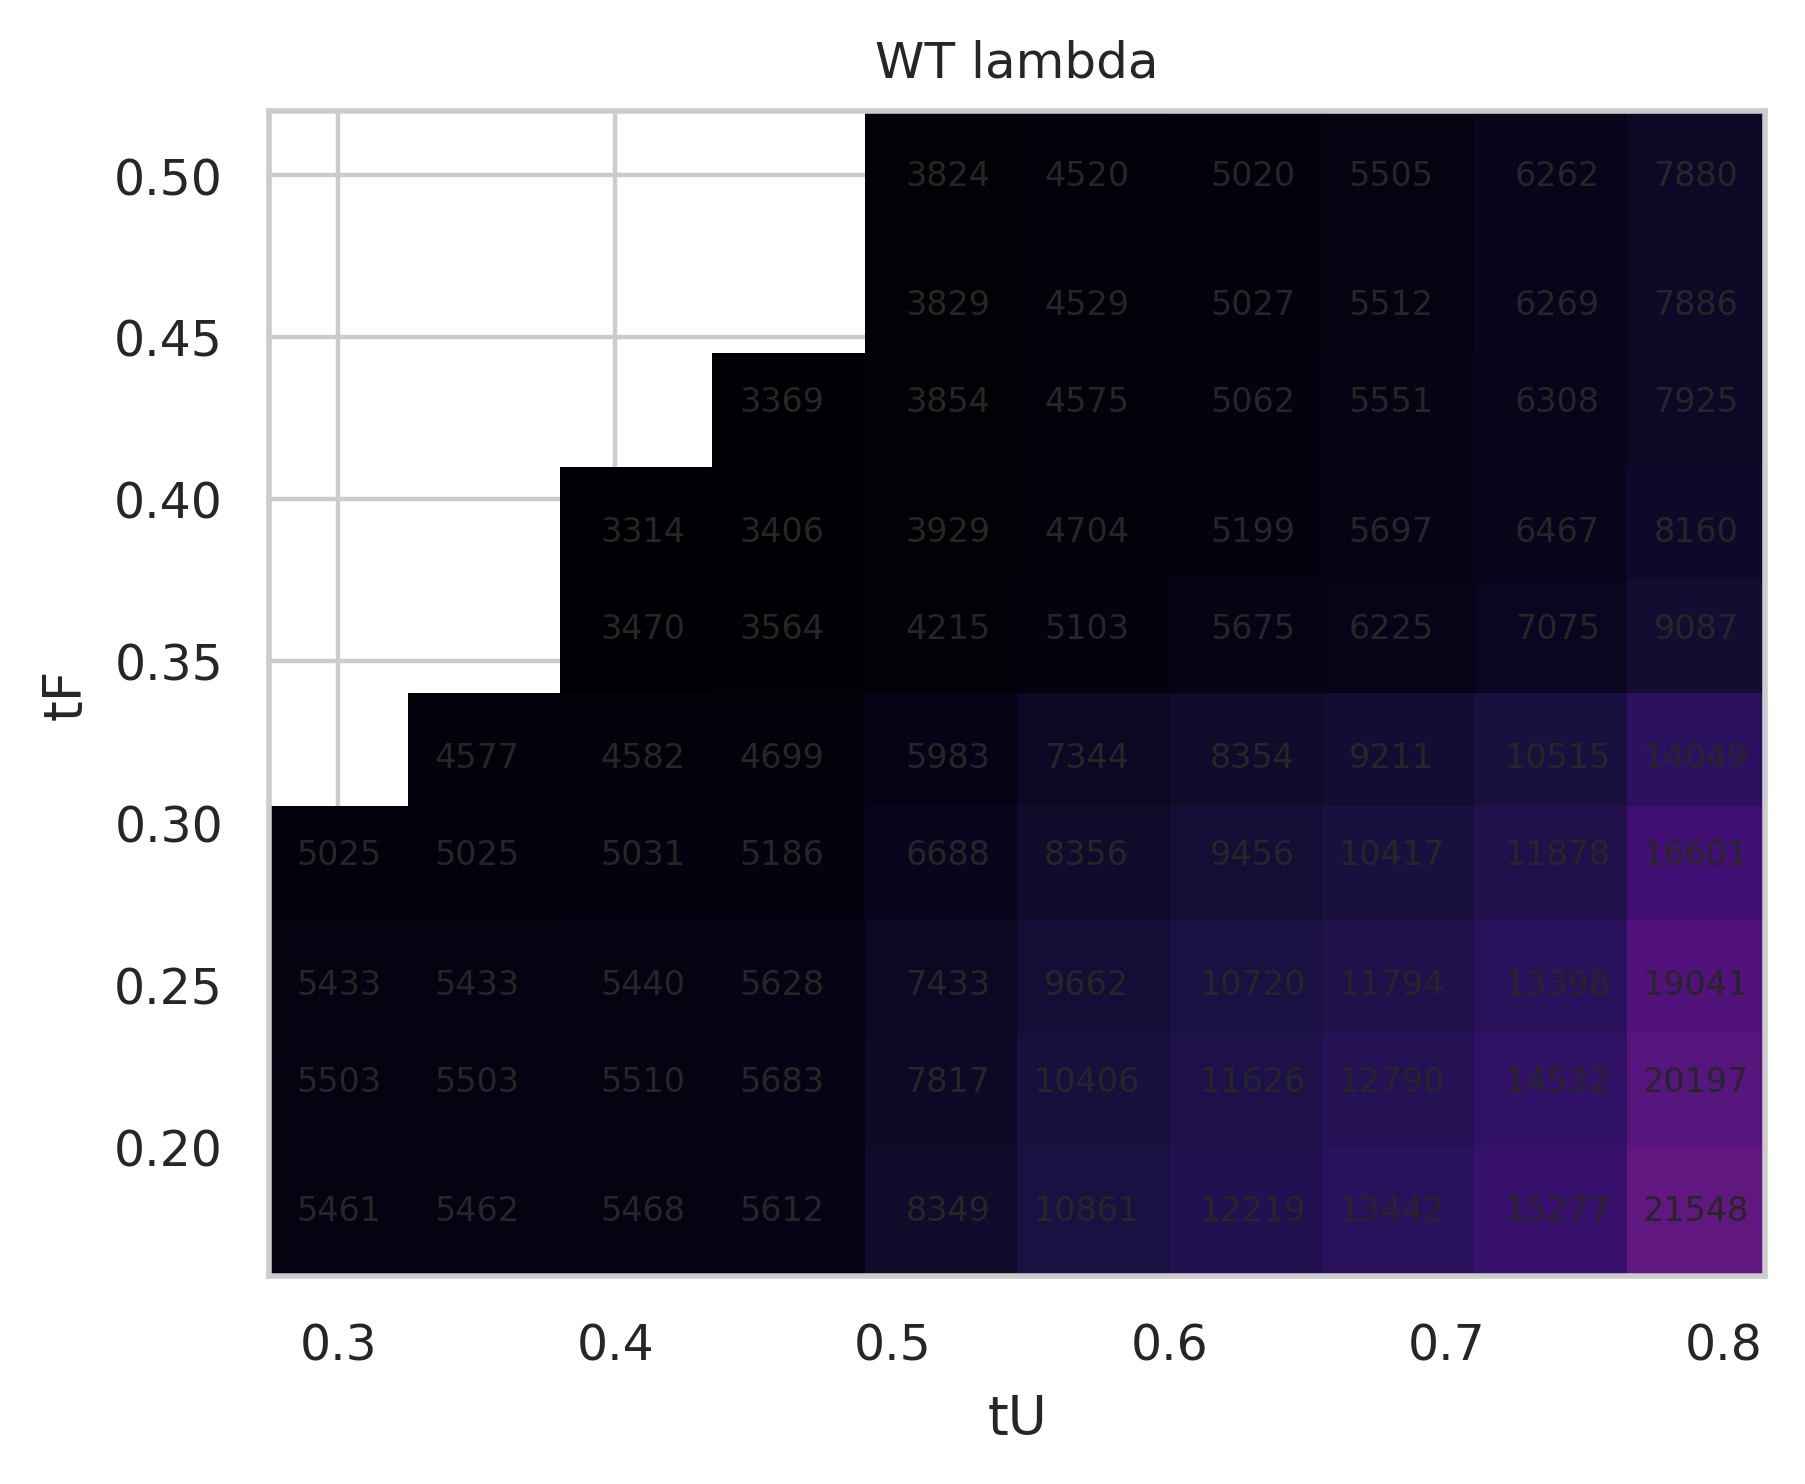

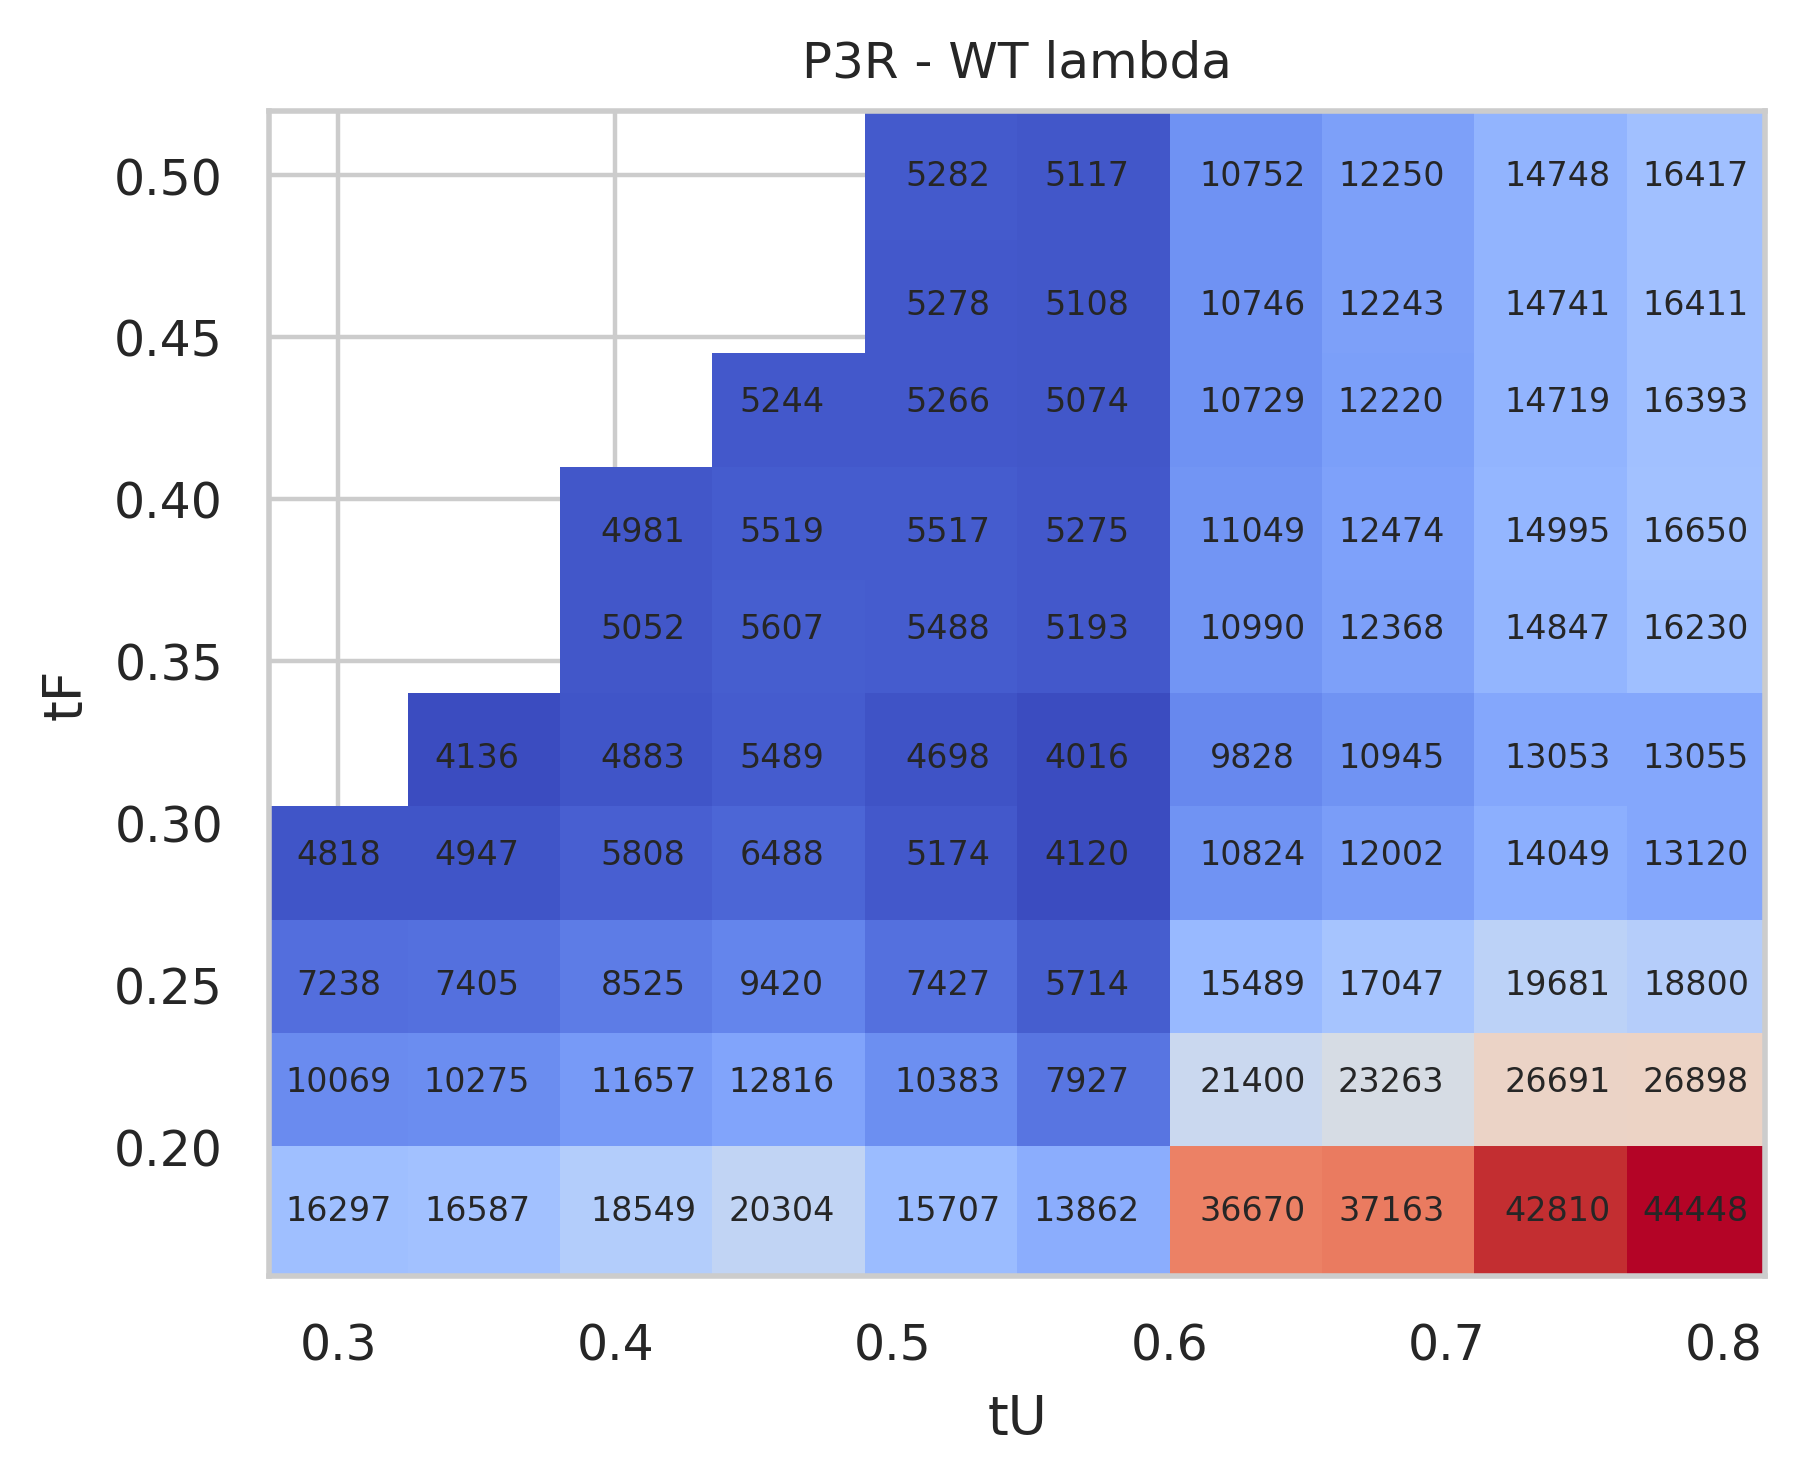

In [7]:
# Lambda heatmaps for P3R vs WT and delta

def lambda_heatmap(mutant, title, vmin=None, vmax=None):
    sub = lambda_grid[lambda_grid['Mutant'] == mutant]
    fig, ax = plt.subplots(figsize=(4.6, 3.8), dpi=200)
    plot_heatmap_in_ax(ax, sub, 'lambda', title, vmin=vmin, vmax=vmax, cmap='magma')
    fig.tight_layout()
    plt.show()

# Shared scale across P3R/WT
p3r_vals = lambda_grid[lambda_grid['Mutant'] == 'P3R']['lambda'].to_numpy()
wt_vals = lambda_grid[lambda_grid['Mutant'] == 'WT']['lambda'].to_numpy()
all_vals = np.concatenate([p3r_vals, wt_vals])
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

lambda_heatmap('P3R', 'P3R lambda', vmin=vmin, vmax=vmax)
lambda_heatmap('WT', 'WT lambda', vmin=vmin, vmax=vmax)

# Delta heatmap (P3R - WT)
merged = lambda_grid[lambda_grid['Mutant'].isin(['P3R', 'WT'])]
p3r = merged[merged['Mutant'] == 'P3R'].set_index(['tF','tU'])
wt = merged[merged['Mutant'] == 'WT'].set_index(['tF','tU'])
delta = (p3r['lambda'] - wt['lambda']).reset_index()

fig, ax = plt.subplots(figsize=(4.6, 3.8), dpi=200)
plot_heatmap_in_ax(ax, delta, 'lambda', 'P3R - WT lambda', cmap='coolwarm')
fig.tight_layout()
plt.show()


In [10]:
# Compare P3 mutants: lambda vs nF/nU at a chosen threshold
# Adjust tF/tU to your default values.

def lambda_summary(mutant, tF, tU):
    row = lambda_grid[(lambda_grid['Mutant'] == mutant) & (lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
    if row.empty:
        return None
    return float(row['lambda'].iloc[0])


def nF_nU(mutant, tF, tU):
    rmsd_F = load_rmsd(mutant, 'COLVAR_CV_F')
    rmsd_U = load_rmsd(mutant, 'COLVAR_CV_UF')
    nF = int(np.sum(rmsd_F <= tF))
    nU = int(np.sum(rmsd_U >= tU))
    return nF, nU


tF = 0.31
tU = 0.68
mutants = ['P3R', 'P3D', 'P3M', 'P3C', 'WT']
rows = []
for mut in mutants:
    lam = lambda_summary(mut, tF, tU)
    nF, nU = nF_nU(mut, tF, tU)
    rows.append({'mutant': mut, 'lambda': lam, 'nF': nF, 'nU': nU})

pd.DataFrame(rows).round(0).astype(int, errors="ignore")


,mutant,lambda,nF,nU
0,P3R,None,80342,27920
1,P3D,None,94959,32292
2,P3M,None,84244,37981
3,P3C,None,96146,38221
4,WT,None,94403,51388
